## Script B-01 - Harvest + Package - Import & Merge Data

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Base data directory
data_dir = Path("Data")


## 1. Load & Combine Harvest Data


In [2]:
# Input files
harvest_files = [
    data_dir / "Track and Trace Data/Cultivation/harvestqty19-24.csv",
    data_dir / "Track and Trace Data/Cultivation/harvestqty23-24.csv",
    data_dir / "Track and Trace Data/Cultivation/harvestqty25.csv"
]

# Output file
output_file = data_dir / "Track and Trace Data/Harvest/harvest.csv"

# Load & concatenate
dfs = [pd.read_csv(file, dtype=str, keep_default_na=False) for file in harvest_files]
harvest_df = pd.concat(dfs, ignore_index=True)

# Save combined
output_file.parent.mkdir(parents=True, exist_ok=True)
harvest_df.to_csv(output_file, index=False)


## 2. Clean Harvest Data

In [3]:
harvest_df = pd.read_csv(
    data_dir / "Track and Trace Data/Harvest/harvest.csv",
    dtype=str,
    keep_default_na=False
)

# Rename columns
harvest_df = harvest_df.rename(columns={
    "HarvesterLicenseNumber": "harvesterlicensenumber",
    "HarvesterFacilityType": "harvesterfacilitytype",
    "HarvesterCity": "harvestercity",
    "HarvesterZipCode": "harvesterzipcode",
    "HarvesterCounty": "harvestercounty",
    "PkgYear": "year",
    "TotalHarvestPounds": "totalharvestpounds",
    "TotalHarvestWetPounds": "totalharvestwetpounds",
    "UniqueHarvestBatches": "uniqueharvestbatches"
})

# Convert numeric
harvest_df["year"] = pd.to_numeric(harvest_df["year"], errors="coerce")
harvest_df["totalharvestpounds"] = pd.to_numeric(harvest_df["totalharvestpounds"], errors="coerce")
harvest_df["totalharvestwetpounds"] = pd.to_numeric(harvest_df["totalharvestwetpounds"], errors="coerce")


## 3. Normalize Harvester County


In [4]:
harvest_df["harvestercounty"] = harvest_df["harvestercounty"].replace(
    {"NA": "", "UNDEFINED": ""}
)

county_map = {
    "Alameda County": "ALAMEDA",
    "El Dorado County": "EL DORADO",
    "Humboldt County": "HUMBOLDT",
    "Imperial County": "IMPERIAL",
    "Inyo County": "INYO",
    "Kern County": "KERN",
    "Kings County": "KINGS",
    "Los Angeles County": "LOS ANGELES",
    "Marin County": "MARIN",
    "Mendocino County": "MENDOCINO",
    "Merced County": "MERCED",
    "Monterey County": "MONTEREY",
    "Nevada County": "NEVADA",
    "Riverside County": "RIVERSIDE",
    "Sacramento County": "SACRAMENTO",
    "San Diego County": "SAN DIEGO",
    "San Francisco County": "SAN FRANCISCO",
    "San Luis Obispo County": "SAN LUIS OBISPO",
    "San Mateo County": "SAN MATEO",
    "Santa Barbara County": "SANTA BARBARA",
    "Santa Cruz County": "SANTA CRUZ",
    "Shasta County": "SHASTA",
    "Sonoma County": "SONOMA",
    "Stanislaus County": "STANISLAUS",
    "Tulare County": "TULARE",
    "Ventura County": "VENTURA",
    "Calaveras County": "CALAVERAS",
    "Lassen County": "LASSEN",
    "Mono County": "MONO",
    "Napa County": "NAPA",
    "San Benito County": "SAN BENITO",
    "San Bernardino County": "SAN BERNARDINO",
    "San Joaquin County": "SAN JOAQUIN",
    "Santa Clara County": "SANTA CLARA",
    "Yuba County": "YUBA",
    "Trinity County": "TRINITY"
}

# normalize harvestercounty
for cannabiz_val, county_val in county_map.items():
    mask = harvest_df["harvestercounty"] == cannabiz_val
    harvest_df.loc[mask, "harvestercounty"] = county_val
    
harvest_df = harvest_df.dropna(subset=["harvestercounty"])
# strip and drop blanks
harvest_df["harvestercounty"] = harvest_df["harvestercounty"].astype(str).str.strip()
harvest_df["harvestercounty"] = harvest_df["harvestercounty"].replace("", pd.NA)
harvest_df["harvestercounty"] = (
    harvest_df["harvestercounty"]
    .astype(str)
    .str.replace(r"\s*County\s*", "", case=False, regex=True)
    .str.strip()
)
harvest_df = harvest_df.dropna(subset=["harvestercounty"])


## 4. Load & Clean Package Data


In [5]:
package_files = [
    data_dir / "Track and Trace Data/Cultivation/packageqty19-24.csv",
    data_dir / "Track and Trace Data/Cultivation/packageqty23-24.csv",
    data_dir / "Track and Trace Data/Cultivation/packageqty25.csv"
]

output_file = data_dir / "Track and Trace Data/Package/package.csv"

dfs = [pd.read_csv(file, dtype=str, keep_default_na=False) for file in package_files]
package_df = pd.concat(dfs, ignore_index=True)

output_file.parent.mkdir(parents=True, exist_ok=True)
package_df.to_csv(output_file, index=False)

package_df = pd.read_csv(
    data_dir / "Track and Trace Data/Package/package.csv",
    dtype=str,
    keep_default_na=False
)

package_df = package_df.rename(columns={
    "HarvesterLicenseNumber": "harvesterlicensenumber",
    "HarvesterFacilityType": "harvesterfacilitytype",
    "HarvesterCity": "harvestercity",
    "HarvesterZipCode": "harvesterzipcode",
    "HarvesterCounty": "harvestercounty",
    "ItemCategory": "itemcategory",
    "Year": "year",
    "TotalPackagePounds": "totalpackagepounds",
    "UniqueHarvestBatches": "uniqueharvestbatches"
})

package_df["year"] = pd.to_numeric(package_df["year"], errors="coerce")
package_df["totalpackagepounds"] = pd.to_numeric(package_df["totalpackagepounds"], errors="coerce")

# Normalize county
for cannabiz_val, county_val in county_map.items():
    mask = package_df["harvestercounty"] == cannabiz_val
    package_df.loc[mask, "harvestercounty"] = county_val
package_df = package_df.dropna(subset=["harvestercounty"])
package_df["harvestercounty"] = package_df["harvestercounty"].astype(str).str.strip()
package_df["harvestercounty"] = package_df["harvestercounty"].replace("", pd.NA)
package_df = package_df.dropna(subset=["harvestercounty"])


## 5. Merge Harvest + Package & Compute Ratios


In [6]:
merged = package_df.merge(
    harvest_df,
    on=["harvesterlicensenumber", "year"],
    how="left",
    suffixes=("_pkg", "_harv")
)

if "harvestercounty_harv" in merged.columns and "harvestercounty_pkg" in merged.columns:
    merged["harvestercounty"] = merged["harvestercounty_harv"].fillna(merged["harvestercounty_pkg"])
elif "harvestercounty_harv" in merged.columns:
    merged["harvestercounty"] = merged["harvestercounty_harv"]
elif "harvestercounty_pkg" in merged.columns:
    merged["harvestercounty"] = merged["harvestercounty_pkg"]

merged["package_to_harvest_ratio"] = merged["totalpackagepounds"] / merged["totalharvestpounds"]
merged["dry_to_wet_ratio"] = merged["totalharvestpounds"] / merged["totalharvestwetpounds"]
merged["category_share"] = merged["totalpackagepounds"] / merged["totalharvestpounds"]

merged["harvestercounty"] = merged["harvestercounty"].astype(str).str.strip()
merged["harvestercounty"] = merged["harvestercounty"].replace("", pd.NA)

merged = merged.dropna(subset=["harvestercounty"])

# replace empty strings and "NA" with real missing values
merged["harvestercounty"] = merged["harvestercounty"].replace(
    {"": pd.NA, "NA": pd.NA, "nan": pd.NA}
)

# drop missing
merged = merged.dropna(subset=["harvestercounty"])


# Script B-02 - Aggregate & Plot


In [7]:
# Category-level aggregation
category_summary = (
    merged.groupby(["harvestercounty", "year", "itemcategory"], as_index=False)
          .agg({
              "totalharvestpounds": "first",
              "totalpackagepounds": "sum",
              "package_to_harvest_ratio": "mean"
          })
)

# County-level aggregation
county_summary = (
    merged.groupby(["harvestercounty", "year"], as_index=False)
          .agg({
              "totalharvestpounds": "first",
              "totalpackagepounds": "sum"
          })
)
county_summary["package_to_harvest_ratio"] = (
    county_summary["totalpackagepounds"] / county_summary["totalharvestpounds"]
)

merged["harvestercounty"] = merged["harvestercounty"].replace(
    {"": pd.NA, "<NA>": pd.NA, "nan": pd.NA}
)
county_summary = county_summary.dropna(subset=["harvestercounty"])
category_summary = (
    merged.groupby(["harvestercounty", "year", "itemcategory"], as_index=False)
          .agg({
              "totalharvestpounds": "first",
              "totalpackagepounds": "sum",
              "package_to_harvest_ratio": "mean"
          })
)

# County-level aggregation
county_summary = (
    merged.groupby(["harvestercounty", "year"], as_index=False)
          .agg({
              "totalharvestpounds": "first",
              "totalpackagepounds": "sum"
          })
)
county_summary["package_to_harvest_ratio"] = (
    county_summary["totalpackagepounds"] / county_summary["totalharvestpounds"]
)

merged["harvestercounty"] = merged["harvestercounty"].replace(
    {"": pd.NA, "<NA>": pd.NA, "nan": pd.NA}
)
county_summary = county_summary.dropna(subset=["harvestercounty"])


# Script B-03 - Export Results


In [8]:
output_path = data_dir / "Results/harvest_package_ratios.xlsx"
county_summary.to_excel(output_path, index=False)


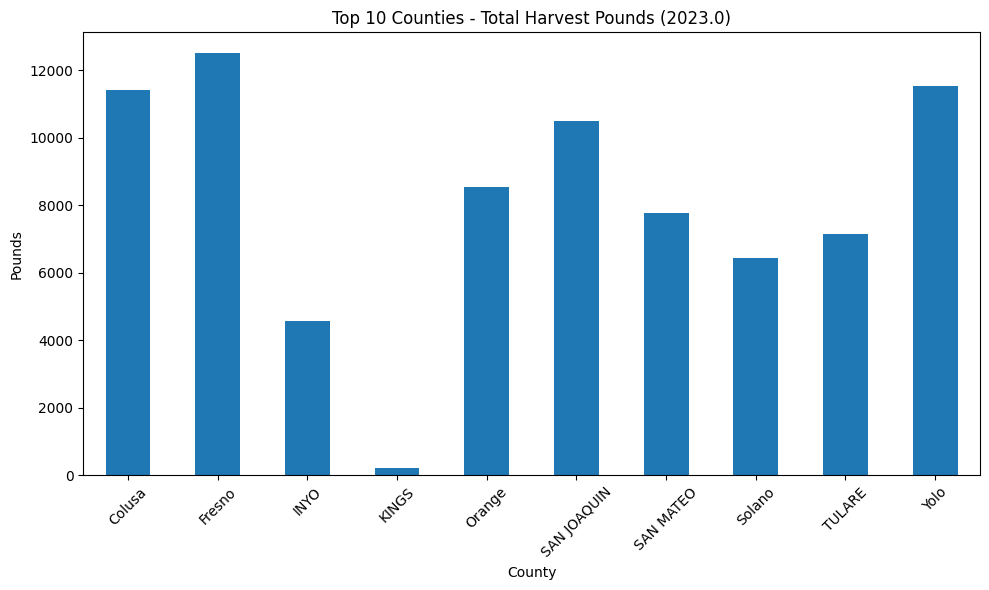

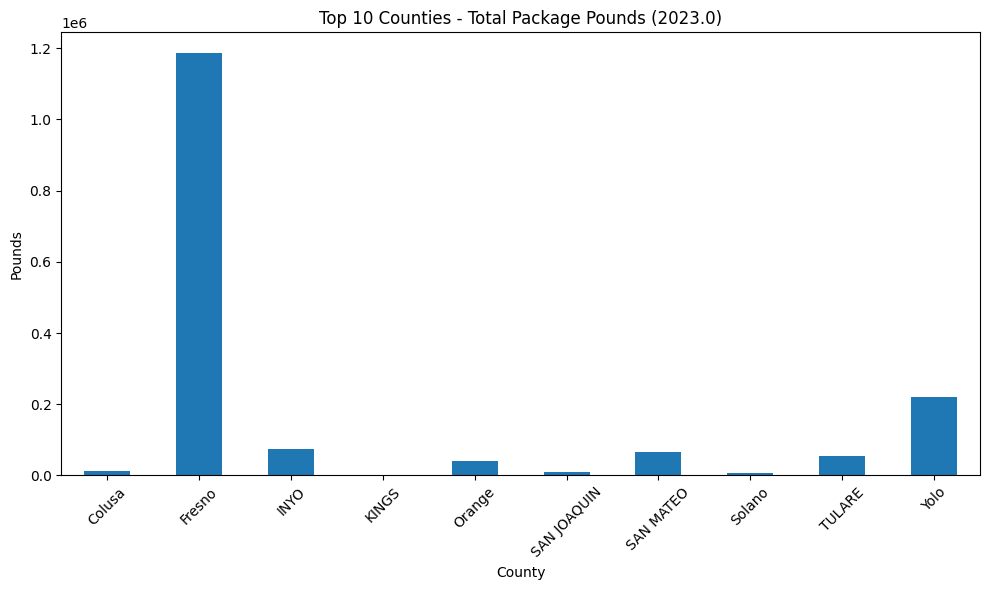

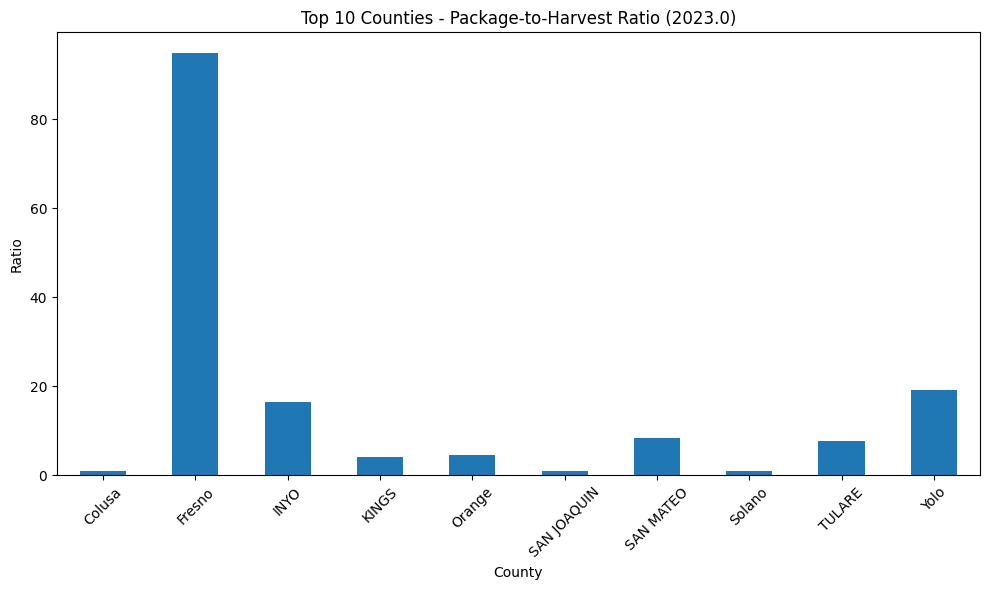

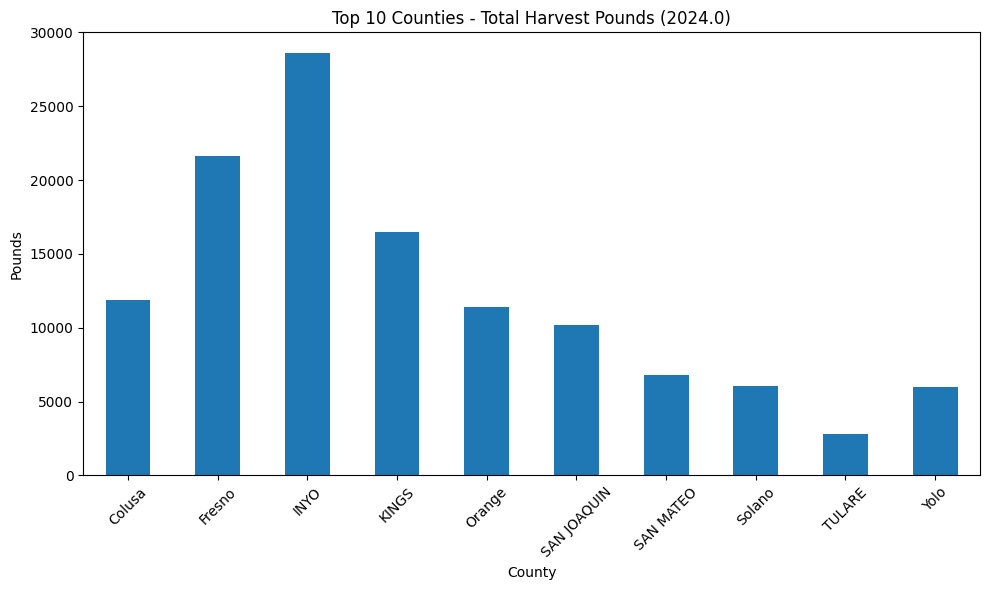

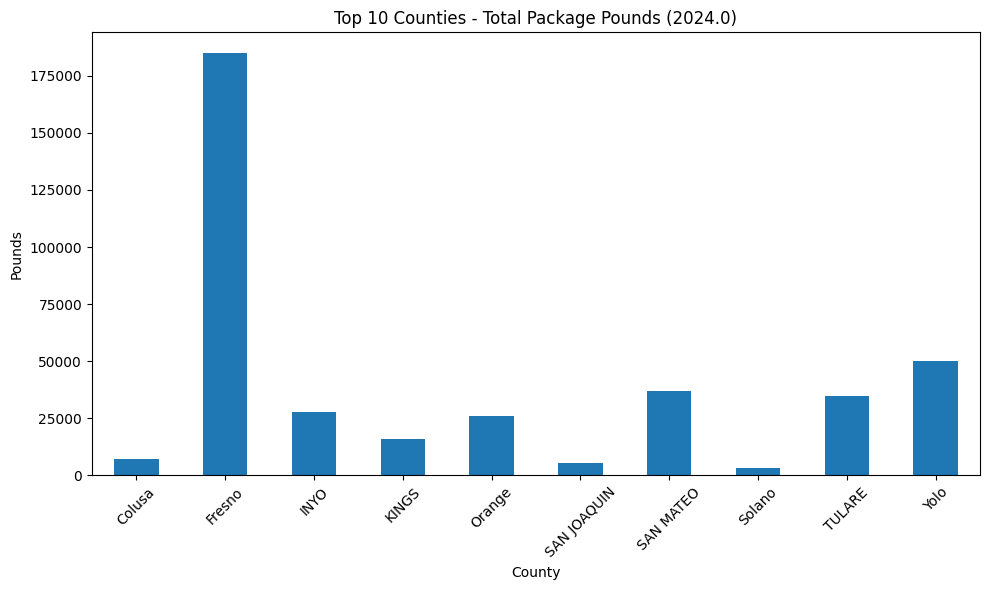

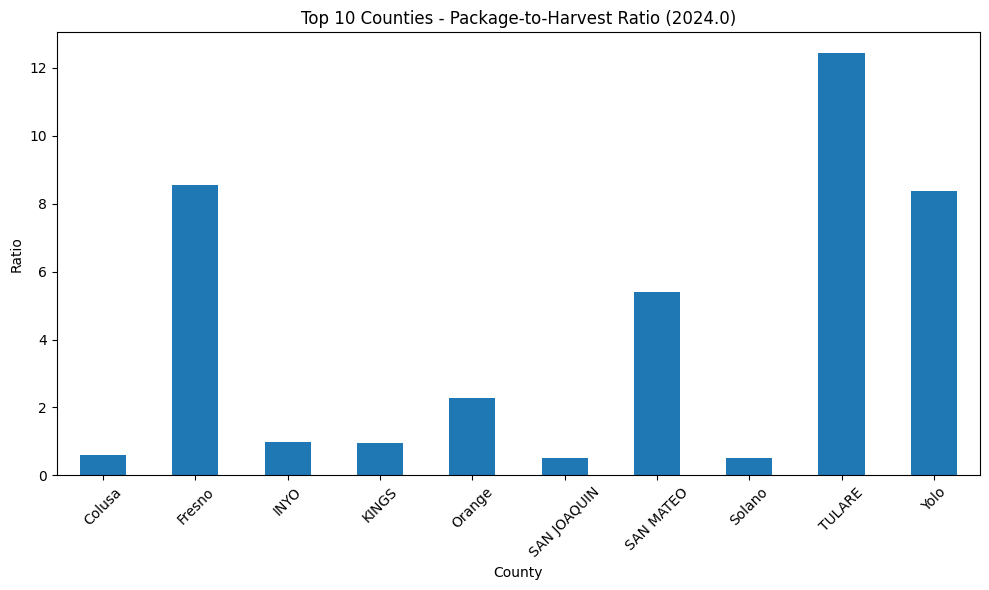

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Pick Top 10 counties based on total harvest pounds across all years
top10 = (
    county_summary.groupby("harvestercounty")["totalharvestpounds"]
    .sum()
    .nlargest(10)
    .index
)

df_top10 = county_summary[county_summary["harvestercounty"].isin(top10)]

# Loop through each year
for year in df_top10["year"].unique():
    df_year = df_top10[df_top10["year"] == year]

    # --- Plot 1: Harvest Pounds ---
    ax = df_year.set_index("harvestercounty")["totalharvestpounds"].plot(
        kind="bar", figsize=(10,6), rot=45
    )
    ax.set_title(f"Top 10 Counties - Total Harvest Pounds ({year})")
    ax.set_ylabel("Pounds")
    ax.set_xlabel("County")
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Package Pounds ---
    ax = df_year.set_index("harvestercounty")["totalpackagepounds"].plot(
        kind="bar", figsize=(10,6), rot=45
    )
    ax.set_title(f"Top 10 Counties - Total Package Pounds ({year})")
    ax.set_ylabel("Pounds")
    ax.set_xlabel("County")
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Package-to-Harvest Ratio ---
    ax = df_year.set_index("harvestercounty")["package_to_harvest_ratio"].plot(
        kind="bar", figsize=(10,6), rot=45
    )
    ax.set_title(f"Top 10 Counties - Package-to-Harvest Ratio ({year})")
    ax.set_ylabel("Ratio")
    ax.set_xlabel("County")
    plt.tight_layout()
    plt.show()
